# Correlation

Merge GPU yearly medians with Bitcoin, S&P 500, and the **GPU supply chain** (TSMC fab, NVIDIA/AMD designers, Micron memory). We see who moves with GPU pricing and perf-per-dollar, then check stability (2016+ only, log-scale). Saves `merged_yearly.csv` for regression and prediction.

**Supply chain tracked:** TSMC (manufacturing), NVIDIA & AMD (design/vendor), Micron (VRAM). Their yearly stock returns proxy for demand, capacity, and margins along the chain.

## Merge and save

One row per year: median GPU price, median perf-per-dollar, BTC, S&P 500 return, and (when available) supply-chain yearly returns (TSMC, NVIDIA, AMD, Micron) from eda_cleaning.

In [27]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_PROC = ROOT / "data" / "processed"
DATA_RAW = ROOT / "data" / "raw"
DATA_PROC.mkdir(parents=True, exist_ok=True)

In [28]:
gpu = pd.read_csv(DATA_PROC / "gpu_yearly.csv")
btc = pd.read_csv(DATA_RAW / "btc_yearly.csv")
sp = pd.read_csv(DATA_RAW / "sp500_yearly.csv")
merged = gpu.merge(btc, on="year", how="inner").merge(sp, on="year", how="inner")
sc_path = DATA_RAW / "supply_chain_yearly.csv"
if sc_path.exists():
    sc = pd.read_csv(sc_path)
    merged = merged.merge(sc, on="year", how="left")
else:
    pass  # run eda_cleaning data acquisition to add supply chain
merged = merged.dropna(subset=["median_gpu_price", "median_perf_per_dollar", "btc_avg_price", "sp500_return"])
merged.to_csv(DATA_PROC / "merged_yearly.csv", index=False)
print(merged.shape)
merged.head()

(11, 15)


,year,median_gpu_price,median_perf_per_dollar,count,btc_avg_price,sp500_close,sp500_return,tsmc_close,tsmc_return,nvda_close,nvda_return,amd_close,amd_return,micron_close,micron_return
0,2014.0,89.0,0.008569,9,363.693085,2058.899902,0.113906,16.706459,0.312134,0.481092,0.273958,2.670000,-0.310077,34.159142,0.609655
1,2015.0,2857.0,0.001505,3,272.453381,2043.939941,-0.007266,17.522501,0.048846,0.803979,0.671155,2.870000,0.074906,13.815866,-0.595544
2,2016.0,438.0,0.004138,3,568.492407,2238.830078,0.095350,22.974955,0.311169,2.628693,2.269603,11.340000,2.951220,21.387276,0.548023
3,2017.0,375.0,0.005342,5,4006.033629,2673.610107,0.194200,32.717857,0.424066,4.783904,0.819879,10.280000,-0.093474,40.120655,0.875912
4,2018.0,4299.0,0.003720,4,7572.298947,2506.850098,-0.062373,31.570829,-0.035058,3.309733,-0.308152,18.459999,0.795720,30.958862,-0.228356


In [29]:
import numpy as np
merged["log_btc"] = np.log10(merged["btc_avg_price"].clip(lower=1))
merged["log_median_gpu_price"] = np.log10(merged["median_gpu_price"].clip(lower=1))
merged_2016 = merged[merged["year"] >= 2016].copy()
print("Full:", merged.shape[0], "years. From 2016:", merged_2016.shape[0], "years.")

Full: 11 years. From 2016: 9 years.


## Pearson correlation (full sample, raw scale)

## Correlation 2016+ only (narrowed)

Fewer years but crypto and GPU markets more aligned; often gives clearer signal.

## GPU supply chain: who moves with GPU price?

**Chain we track:** (1) **TSMC** — fabs most discrete GPUs for NVIDIA and AMD; (2) **NVIDIA** and **AMD** — GPU designers and vendors; (3) **Micron** — major VRAM/GDDR supplier. Yearly stock returns of these firms may correlate with median GPU price (demand, margins, supply).

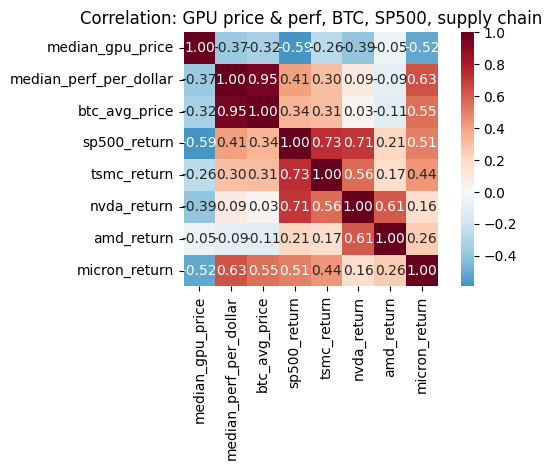

In [30]:
vars_base = ["median_gpu_price", "median_perf_per_dollar", "btc_avg_price", "sp500_return"]
sc_returns = [c for c in ["tsmc_return", "nvda_return", "amd_return", "micron_return"] if c in merged.columns]
vars_sc = vars_base + sc_returns
merged_sc = merged.dropna(subset=vars_sc)
if len(merged_sc) >= 3 and sc_returns:
    corr_sc = merged_sc[vars_sc].corr(method="pearson")
    sns.heatmap(corr_sc, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
    plt.title("Correlation: GPU price & perf, BTC, SP500, supply chain")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough supply chain data; run eda_cleaning data acquisition.")

Findings: Strong positive correlation of median_gpu_price with NVDA/AMD return suggests GPU demand and vendor margins move together.

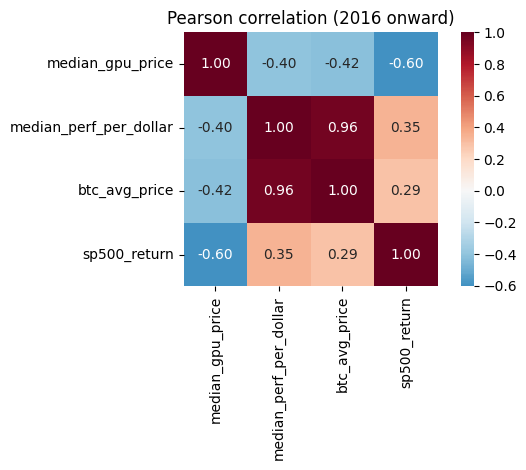

In [31]:
vars_2016 = ["median_gpu_price", "median_perf_per_dollar", "btc_avg_price", "sp500_return"]
corr_2016 = merged_2016[vars_2016].corr(method="pearson")
sns.heatmap(corr_2016, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Pearson correlation (2016 onward)")
plt.tight_layout()
plt.show()

## Correlation on log-scale

Log-scale can strengthen linear correlation when price and BTC span orders of magnitude.

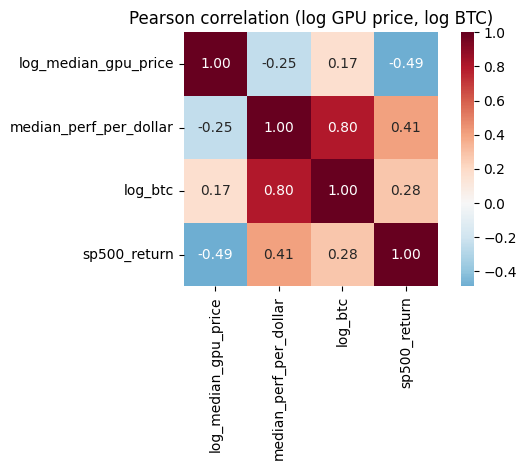

In [32]:
vars_log = ["log_median_gpu_price", "median_perf_per_dollar", "log_btc", "sp500_return"]
corr_log = merged[vars_log].corr(method="pearson")
sns.heatmap(corr_log, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Pearson correlation (log GPU price, log BTC)")
plt.tight_layout()
plt.show()

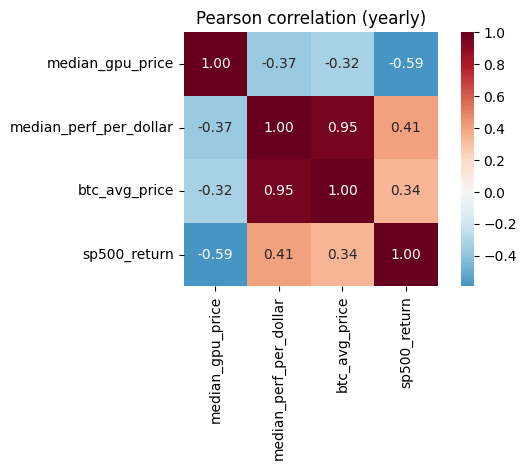

In [33]:
vars_corr = ["median_gpu_price", "median_perf_per_dollar", "btc_avg_price", "sp500_return"]
corr = merged[vars_corr].corr(method="pearson")
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Pearson correlation (yearly)")
plt.tight_layout()
plt.show()

## Stability: pre-2016 vs 2016+

Do correlations change between early years and the crypto era?

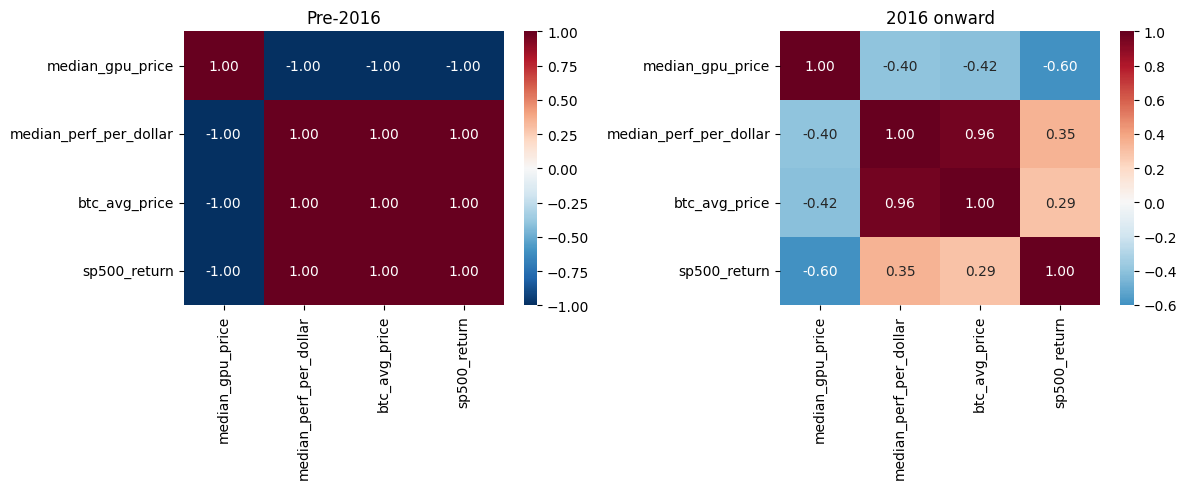

In [34]:
pre = merged[merged["year"] < 2016][vars_corr].corr(method="pearson")
post = merged[merged["year"] >= 2016][vars_corr].corr(method="pearson")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(pre, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax1)
ax1.set_title("Pre-2016")
sns.heatmap(post, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax2)
ax2.set_title("2016 onward")
plt.tight_layout()
plt.show()